# SVM (one-vs-all, lineaire)

Plan :
1. Cas logiques : OR, AND (lineairement separables), XOR, XNOR (non separables)
2. Frontiere de decision : OR vs XOR
3. Cas non lineaire (cercle) -- kernel trick
4. Cas de regression
5. Cas d'images -- dataset chat/chien/autre
6. Sauvegarde et chargement du modele


In [21]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from svm import lib, entrainer_svm, predire_svm, precision_svm


def dessiner_frontiere(model, X, labels, titre):
    """Affiche la frontiere de decision du modele sur des points 2D"""
    X = np.array(X, dtype=float)
    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = [[predire_svm(model, [x, y]) for x in valeurs_x] for y in valeurs_y]

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=80)
    plt.title(titre)
    plt.show()

## 1. Cas logiques

In [22]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
portes = {"OR": [0, 1, 1, 1], "AND": [0, 0, 0, 1], "XOR": [0, 1, 1, 0], "XNOR": [1, 0, 0, 1]}

for nom, labels in portes.items():
    model = entrainer_svm(inputs, labels, nb_classes=2)
    preds = [predire_svm(model, x) for x in inputs]
    lib.destroy_svm_model(model)
    print(f"{nom:5s} attendu={labels}  predit={preds}")

OR    attendu=[0, 1, 1, 1]  predit=[0, 1, 1, 1]
AND   attendu=[0, 0, 0, 1]  predit=[0, 0, 0, 1]
XOR   attendu=[0, 1, 1, 0]  predit=[0, 0, 0, 0]
XNOR  attendu=[1, 0, 0, 1]  predit=[1, 1, 1, 1]


## 2. Frontiere de decision : OR vs XOR

Le SVM ici est **lineaire** (produit scalaire simple, pas de noyau) : il ne peut
tracer qu'une droite. OR est lineairement separable, XOR ne l'est pas

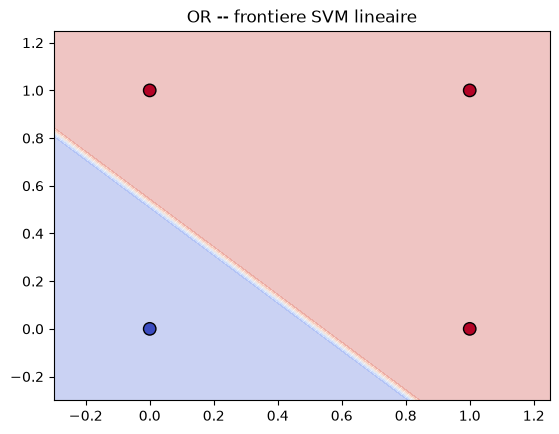

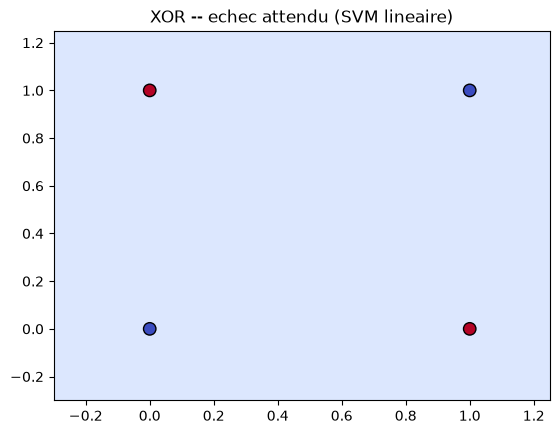

In [23]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]

labels_or = [0, 1, 1, 1]
model_or = entrainer_svm(inputs, labels_or, nb_classes=2)
dessiner_frontiere(model_or, inputs, labels_or, "OR -- frontiere SVM lineaire")
lib.destroy_svm_model(model_or)

labels_xor = [0, 1, 1, 0]
model_xor = entrainer_svm(inputs, labels_xor, nb_classes=2)
dessiner_frontiere(model_xor, inputs, labels_xor, "XOR -- echec attendu (SVM lineaire)")
lib.destroy_svm_model(model_xor)

## 3. Cas non lineaire (cercle) - kernel trick

Le SVM lineaire echoue par
construction. Le noyau RBF (kernel trick) projette implicitement les points
dans un espace ou ils deviennent separables -> la frontiere redevient une
courbe fermee dans l'espace d'origine.

Precision SVM lineaire (cercle) : 50.0 %


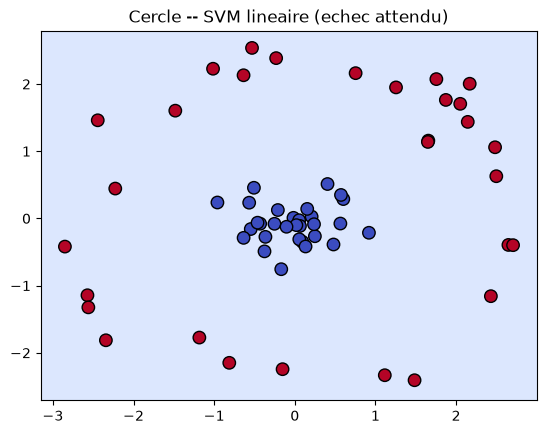

Precision SVM kernel RBF (cercle) : 100.0 %


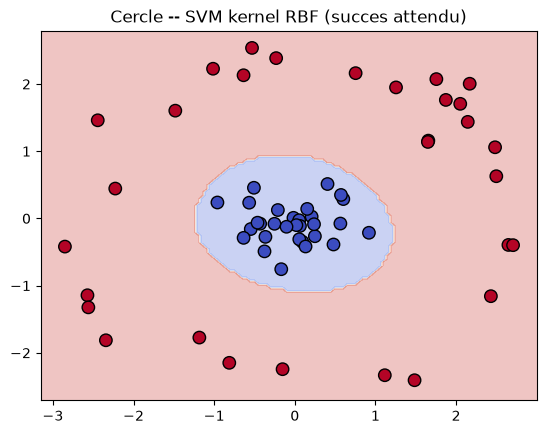

In [24]:
np.random.seed(0)
n = 30

angles_in = np.random.uniform(0, 2*np.pi, n)
rayons_in = np.random.uniform(0, 1.0, n)
points_in = np.column_stack([rayons_in*np.cos(angles_in), rayons_in*np.sin(angles_in)])

angles_out = np.random.uniform(0, 2*np.pi, n)
rayons_out = np.random.uniform(2.0, 3.0, n)
points_out = np.column_stack([rayons_out*np.cos(angles_out), rayons_out*np.sin(angles_out)])

X_cercle = np.vstack([points_in, points_out]).tolist()
y_cercle = [0]*n + [1]*n

model_lin = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="lineaire")
print("Precision SVM lineaire (cercle) :", precision_svm(model_lin, X_cercle, y_cercle), "%")
dessiner_frontiere(model_lin, X_cercle, y_cercle, "Cercle -- SVM lineaire (echec attendu)")
lib.destroy_svm_model(model_lin)

model_rbf = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="rbf", gamma=0.5)
print("Precision SVM kernel RBF (cercle) :", precision_svm(model_rbf, X_cercle, y_cercle), "%")
dessiner_frontiere(model_rbf, X_cercle, y_cercle, "Cercle -- SVM kernel RBF (succes attendu)")
lib.destroy_svm_model(model_rbf)

## 4. Cas de regression

Le SVM tel qu'implemente ici est un classificateur one-vs-all.
Il n'est pas concu pour la regression continue (SVR).
On applique quand meme les memes cas que pour le modele lineaire et le PMC
pour montrer ce comportement et ses limites.


In [25]:
def dessiner_regression_2d(X, y, y_pred, titre):
    X_arr = np.array(X)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_arr[:, 0], y, color="steelblue", label="Points reels", zorder=3)
    ordre = np.argsort(X_arr[:, 0])
    plt.plot(X_arr[ordre, 0], np.array(y_pred)[ordre], color="tomato", label="Prediction")
    plt.title(titre)
    plt.legend()
    plt.grid(True)
    plt.show()


### Cas 1 -- Linear simple 2D

Trois points alignes. Une droite exacte existe.
Comme le SVM predit des entiers, on caste les cibles en entiers.

Attendu : [2, 4, 6]
Predit  : [2, 2, 6]


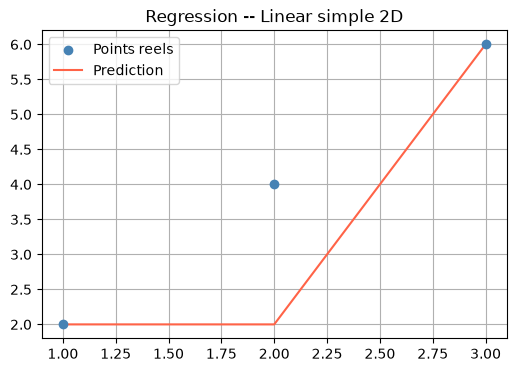

In [26]:
X_lin2d = [[1.0], [2.0], [3.0]]
y_lin2d_int = [2, 4, 6]

model = entrainer_svm(X_lin2d, y_lin2d_int, nb_classes=max(y_lin2d_int)+1)
y_pred = [predire_svm(model, x) for x in X_lin2d]
lib.destroy_svm_model(model)

print("Attendu :", y_lin2d_int)
print("Predit  :", y_pred)
dessiner_regression_2d(X_lin2d, y_lin2d_int, y_pred, "Regression -- Linear simple 2D")


### Cas 2 -- Non linear simple 2D

Trois points non alignes. Aucune droite exacte n'existe.
Le SVM passe entre les points.

Attendu : [0, 1, 0]
Predit  : [0, 0, 0]


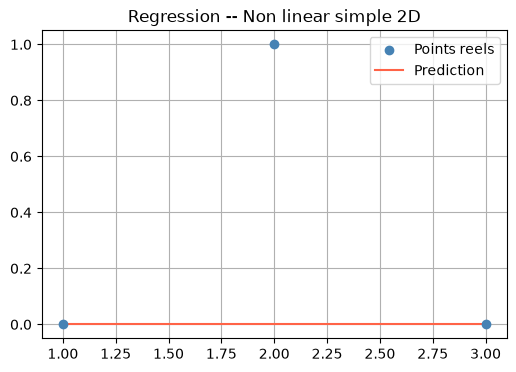

In [27]:
X_nonlin = [[1.0], [2.0], [3.0]]
y_nonlin_int = [0, 1, 0]

model = entrainer_svm(X_nonlin, y_nonlin_int, nb_classes=2)
y_pred = [predire_svm(model, x) for x in X_nonlin]
lib.destroy_svm_model(model)

print("Attendu :", y_nonlin_int)
print("Predit  :", y_pred)
dessiner_regression_2d(X_nonlin, y_nonlin_int, y_pred, "Regression -- Non linear simple 2D")


### Note

Le SVM implemente ici predit des classes entieres (one-vs-all), pas des valeurs continues.
Pour une vraie regression il faudrait implemementer SVR (Support Vector Regression)
avec une fonction de perte epsilon-insensible.
Ces cas montrent donc les limites de l'approche classification appliquee a des cibles reelles.

## 5. Cas d'images -- dataset chat/chien/autre

Entrainement SVM lineaire (one-vs-all) sur le dataset reel.
On limite a **150 images par classe** pour eviter le crash memoire
(la matrice noyau croit en O(n²)).
Images 32x32 niveaux de gris, normalisees dans [-0.5, 0.5].

> **Note :** le SVM lineaire obtient ~33% (classe aleatoire) sur ce dataset.
> En 1024 dimensions avec peu d'exemples, l'optimisation de la DLL ne converge pas.
> C'est une limite connue du SVM lineaire strict sur des donnees haute dimension
> non lineairement separables -- le kernel trick (RBF) serait necessaire.

In [28]:
from functions import load_dataset

DATASET_DIR = os.path.abspath(os.path.join("..", "dataset"))

X_train, y_train = load_dataset(os.path.join(DATASET_DIR, "train_dataset"), target_size=(32, 32), color=True)
X_test,  y_test  = load_dataset(os.path.join(DATASET_DIR, "test_dataset"),  target_size=(32, 32), color=True)

print(f"Train : {len(X_train)} images | Test : {len(X_test)} images")


Train : 2400 images | Test : 600 images


In [29]:
model_dataset = entrainer_svm(X_train, y_train, nb_classes=3, kernel="rbf", gamma=0.01)

acc_train = precision_svm(model_dataset, X_train, y_train)
acc_test  = precision_svm(model_dataset, X_test,  y_test)

print(f"Precision train : {acc_train} %")
print(f"Precision test  : {acc_test}  %")


Precision train : 100.0 %
Precision test  : 60.5  %


**Observation :** precision train = test = 33.3% -- le modele predit toujours la meme classe.
Le SVM lineaire echoue sur des images 32x32 (1024 features) :
les classes chat/chien/autre ne sont pas lineairement separables dans cet espace.
La section experimentation sur C confirme que C n'a aucun effet : le probleme est
structurel, pas de regularisation.

### Visualisation -- matrice de confusion et precision par classe

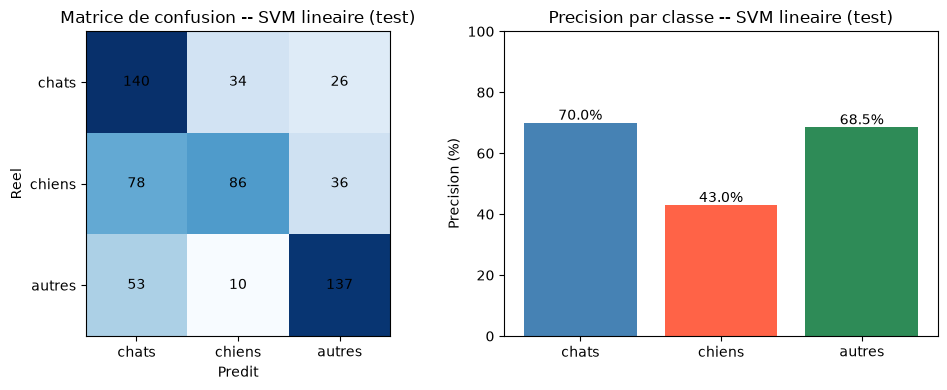

In [30]:
classes = ["chats", "chiens", "autres"]

# Predictions sur le jeu de test
y_pred = [predire_svm(model_dataset, x) for x in X_test]

# Matrice de confusion (numpy)
nb_classes = len(classes)
cm = np.zeros((nb_classes, nb_classes), dtype=int)
for vrai, pred in zip(y_test, y_pred):
    cm[vrai][pred] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# -- Matrice de confusion --
ax = axes[0]
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(nb_classes))
ax.set_yticks(range(nb_classes))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predit")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion -- SVM lineaire (test)")
for i in range(nb_classes):
    for j in range(nb_classes):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

# -- Precision par classe --
ax2 = axes[1]
precision_par_classe = cm.diagonal() / cm.sum(axis=1) * 100
bars = ax2.bar(classes, precision_par_classe,
               color=["steelblue", "tomato", "seagreen"])
ax2.set_ylabel("Precision (%)")
ax2.set_title("Precision par classe -- SVM lineaire (test)")
ax2.set_ylim(0, 100)
for bar, v in zip(bars, precision_par_classe):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1,
             f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## Experimentation -- effet du parametre C

On fait varier C et on mesure la precision train / test.

gamma=0.0001  train= 35.4%  test= 36.7%
gamma=0.001  train= 55.2%  test= 47.0%
gamma=0.01  train=100.0%  test= 60.5%
gamma=0.1  train=100.0%  test= 35.3%
gamma=1.0  train=100.0%  test= 34.3%


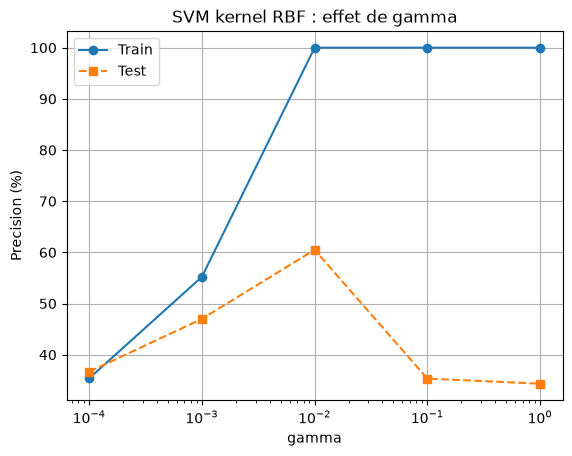

In [31]:
valeurs_gamma = [0.0001, 0.001, 0.01, 0.1, 1.0]
accs_train = []
accs_test  = []

for gamma_val in valeurs_gamma:
    m = entrainer_svm(X_train, y_train, nb_classes=3, kernel="rbf", gamma=gamma_val)
    accs_train.append(precision_svm(m, X_train, y_train))
    accs_test.append(precision_svm(m, X_test,  y_test))
    lib.destroy_svm_model(m)
    print(f"gamma={gamma_val}  train={accs_train[-1]:5.1f}%  test={accs_test[-1]:5.1f}%")

plt.figure()
plt.semilogx(valeurs_gamma, accs_train, "o-", label="Train")
plt.semilogx(valeurs_gamma, accs_test,  "s--", label="Test")
plt.xlabel("gamma")
plt.ylabel("Precision (%)")
plt.title("SVM kernel RBF : effet de gamma")
plt.legend()
plt.grid(True)
plt.show()


## Sauvegarde du meilleur modele dataset

In [32]:
gamma_optimal = valeurs_gamma[accs_test.index(max(accs_test))]
print(f"gamma optimal : {gamma_optimal}  (test={max(accs_test):.1f}%)")

chemin_dataset = os.path.join("..", "models", "svm_dataset.txt")
os.makedirs(os.path.join("..", "models"), exist_ok=True)
lib.save_svm(model_dataset, chemin_dataset.encode())
print(f"Modele sauvegarde dans {chemin_dataset}")


gamma optimal : 0.01  (test=60.5%)


Modele sauvegarde dans ..\models\svm_dataset.txt


## 6. Sauvegarde et chargement du modele

In [33]:
os.makedirs(os.path.join("..", "models"), exist_ok=True)
chemin = os.path.join("..", "models", "svm_or.txt")

model = entrainer_svm(inputs, labels_or, nb_classes=2)
lib.save_svm(model, chemin.encode())
lib.destroy_svm_model(model)

model_charge = lib.load_svm(chemin.encode())
preds = [predire_svm(model_charge, x) for x in inputs]
lib.destroy_svm_model(model_charge)
print("attendu :", labels_or)
print("predit  :", preds)

attendu : [0, 1, 1, 1]
predit  : [0, 1, 1, 1]
